In [2]:
import numpy as np, pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (summarize,poly,ModelSpec as MS)

In [3]:
from pygam import (s as s_gam, LinearGAM)
from ISLP.transforms import (BSpline,NaturalSpline)
from ISLP.models import bs, ns

In [5]:
Wage = load_data('Wage')
y = Wage['wage']
age = Wage['age']

In [8]:
poly_age = MS([poly('age', degree=4)]).fit(Wage)
M = sm.OLS(y, poly_age.transform(Wage)).fit()
summarize(M)

,coef,std err,t,P>|t|
intercept,111.7036,0.729,153.283,0.000
"poly(age, degree=4)[0]",447.0679,39.915,11.201,0.000
"poly(age, degree=4)[1]",-478.3158,39.915,-11.983,0.000
"poly(age, degree=4)[2]",125.5217,39.915,3.145,0.002
"poly(age, degree=4)[3]",-77.9112,39.915,-1.952,0.051


In [12]:
age_grid = np.linspace(age.min(),age.max(),100)
age_df = pd.DataFrame({'age':age_grid})

In [10]:
age

0       18
1       24
2       45
3       43
4       50
        ..
2995    44
2996    30
2997    27
2998    27
2999    55
Name: age, Length: 3000, dtype: int64

In [13]:
age_df

,age
0,18.000000
1,18.626263
2,19.252525
3,19.878788
4,20.505051
...,...
95,77.494949
96,78.121212
97,78.747475
98,79.373737


In [20]:
def plot_wage_fit(age_df, basis,title):
    X = basis.transform(Wage)
    Xnew = basis.transform(age_df)
    M = sm.OLS(y,X).fit()
    preds = M.get_prediction(Xnew)
    bands = preds.conf_int(alpha=0.05)
    fig, ax = subplots(figsize=(8,8)) 
    ax.scatter(age,y,facecolor='gray',alpha = 0.5)
    for val, ls in zip([preds.predicted_mean, bands[:,0], bands[:,1]],['b','r--','r--']):
        ax.plot(age_df.values, val, ls, linewidth = 3)
    ax.set_title(title, fontsize=20)
    ax.set_xlabel('Age', fontsize=20)
    ax.set_ylabel('Wage' ,fontsize=20);
    return ax

<Axes: title={'center': 'Degree-4 Polynomial'}, xlabel='Age', ylabel='Wage'>

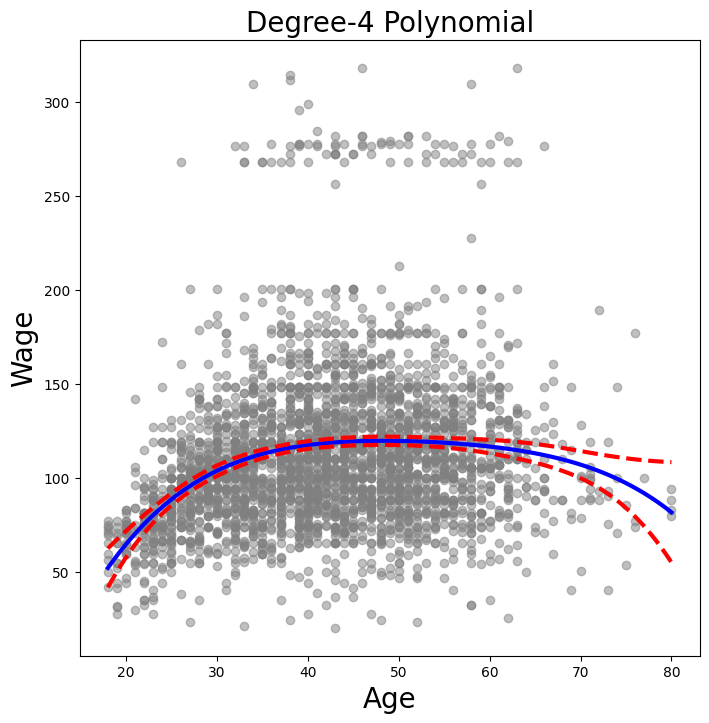

In [21]:
plot_wage_fit(age_df, poly_age,'Degree-4 Polynomial')

In [27]:
poly_age1 = MS([poly('age', degree=5)]).fit(Wage)
M = sm.OLS(y, poly_age1.transform(Wage)).fit()
summarize(M)

,coef,std err,t,P>|t|
intercept,111.7036,0.729,153.278,0.000
"poly(age, degree=5)[0]",447.0679,39.916,11.200,0.000
"poly(age, degree=5)[1]",-478.3158,39.916,-11.983,0.000
"poly(age, degree=5)[2]",125.5217,39.916,3.145,0.002
"poly(age, degree=5)[3]",-77.9112,39.916,-1.952,0.051
"poly(age, degree=5)[4]",-35.8129,39.916,-0.897,0.370


<Axes: title={'center': 'Degree-5 Polynomial'}, xlabel='Age', ylabel='Wage'>

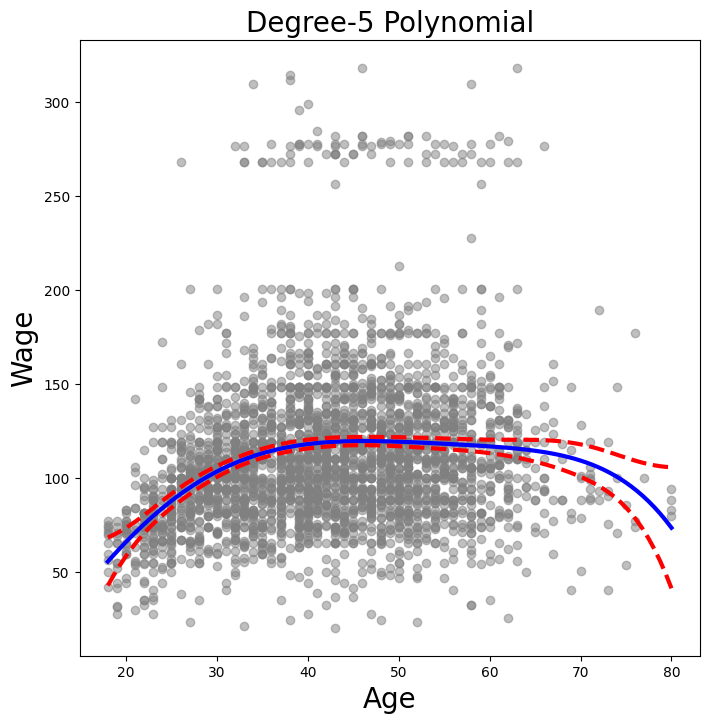

In [28]:
 plot_wage_fit(age_df, poly_age1, 'Degree-5 Polynomial')

In [30]:
X = poly_age.transform(Wage)
high_earn = Wage['high_earn'] = y > 250
glm = sm.GLM(y > 250, X, family=sm.families.Binomial())
B = glm.fit()
summarize(B)

,coef,std err,z,P>|z|
intercept,-4.3012,0.345,-12.457,0.000
"poly(age, degree=4)[0]",71.9642,26.133,2.754,0.006
"poly(age, degree=4)[1]",-85.7729,35.929,-2.387,0.017
"poly(age, degree=4)[2]",34.1626,19.697,1.734,0.083
"poly(age, degree=4)[3]",-47.4008,24.105,-1.966,0.049


In [31]:
newX = poly_age.transform(age_df)
preds = B.get_prediction(newX)
bands = preds.conf_int(alpha = 0.05)

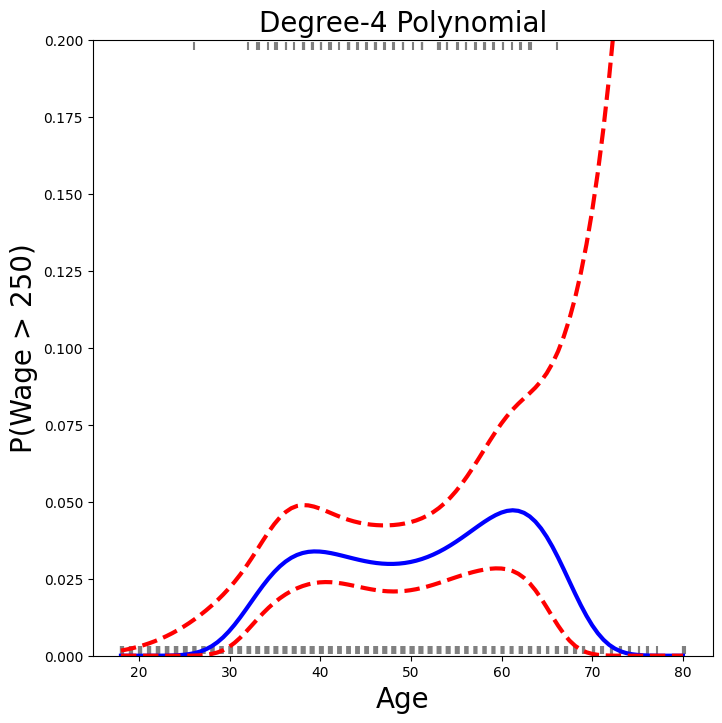

In [32]:
fig, ax = subplots(figsize=(8,8))
rng = np.random.default_rng(0)
ax.scatter(age +
           0.2 * rng.uniform(size=y.shape[0]),
           np.where(high_earn, 0.198, 0.002),
           fc='gray',
           marker='|')
for val, ls in zip([preds.predicted_mean,
                  bands[:,0],
                  bands[:,1]],
                 ['b','r--','r--']):
    ax.plot(age_df.values, val, ls, linewidth=3)
ax.set_title('Degree-4 Polynomial', fontsize=20)
ax.set_xlabel('Age', fontsize=20)
ax.set_ylim([0,0.2])
ax.set_ylabel('P(Wage > 250)', fontsize=20);

In [33]:
pd.qcut?

Signature:
pd.qcut(
    x,
    q,
    labels=None,
    retbins: 'bool' = False,
    precision: 'int' = 3,
    duplicates: 'str' = 'raise',
)
Docstring:
Quantile-based discretization function.

Discretize variable into equal-sized buckets based on rank or based
on sample quantiles. For example 1000 values for 10 quantiles would
produce a Categorical object indicating quantile membership for each data point.

Parameters
----------
x : 1d ndarray or Series
q : int or list-like of float
    Number of quantiles. 10 for deciles, 4 for quartiles, etc. Alternately
    array of quantiles, e.g. [0, .25, .5, .75, 1.] for quartiles.
labels : array or False, default None
    Used as labels for the resulting bins. Must be of the same length as
    the resulting bins. If False, return only integer indicators of the
    bins. If True, raises an error.
retbins : bool, optional
    Whether to return the (bins, labels) or not. Can be useful if bins
    is given as a scalar.
precision : int, optional
    

In [34]:
cut_age = pd.qcut(age,4)
summarize(sm.OLS(y,pd.get_dummies(cut_age)).fit())

,coef,std err,t,P>|t|
"(17.999, 33.75]",94.1584,1.478,63.692,0.0
"(33.75, 42.0]",116.6608,1.470,79.385,0.0
"(42.0, 51.0]",119.1887,1.416,84.147,0.0
"(51.0, 80.0]",116.5717,1.559,74.751,0.0


In [36]:
bs_ = BSpline(internal_knots=[25,40,60],intercept=True).fit(age)
bs_age = bs_.transform(age)
bs_age.shape

(3000, 7)

In [37]:
bs_age = MS([bs('age', internal_knots=[25,40,60])])
Xbs = bs_age.fit_transform(Wage)
M = sm.OLS(y,Xbs).fit()
summarize(M) 

,coef,std err,t,P>|t|
intercept,60.4937,9.460,6.394,0.000
"bs(age, internal_knots=[25, 40, 60])[0]",3.9805,12.538,0.317,0.751
"bs(age, internal_knots=[25, 40, 60])[1]",44.6310,9.626,4.636,0.000
"bs(age, internal_knots=[25, 40, 60])[2]",62.8388,10.755,5.843,0.000
"bs(age, internal_knots=[25, 40, 60])[3]",55.9908,10.706,5.230,0.000
"bs(age, internal_knots=[25, 40, 60])[4]",50.6881,14.402,3.520,0.000
"bs(age, internal_knots=[25, 40, 60])[5]",16.6061,19.126,0.868,0.385


In [38]:
bs_age = MS([bs('age',
                internal_knots=[25,40,60],
                name='bs(age)')])
Xbs = bs_age.fit_transform(Wage)
M = sm.OLS(y, Xbs).fit()
summarize(M)

,coef,std err,t,P>|t|
intercept,60.4937,9.460,6.394,0.000
bs(age)[0],3.9805,12.538,0.317,0.751
bs(age)[1],44.6310,9.626,4.636,0.000
bs(age)[2],62.8388,10.755,5.843,0.000
bs(age)[3],55.9908,10.706,5.230,0.000
bs(age)[4],50.6881,14.402,3.520,0.000
bs(age)[5],16.6061,19.126,0.868,0.385


In [39]:
BSpline(df=6).fit(age).internal_knots_

array([33.75, 42.  , 51.  ])

In [40]:
bs_age0 = MS([bs('age',
                 df=3, 
                 degree=0)]).fit(Wage)
Xbs0 = bs_age0.transform(Wage)
summarize(sm.OLS(y, Xbs0).fit())

,coef,std err,t,P>|t|
intercept,94.1584,1.478,63.687,0.0
"bs(age, df=3, degree=0)[0]",22.3490,2.152,10.388,0.0
"bs(age, df=3, degree=0)[1]",24.8076,2.044,12.137,0.0
"bs(age, df=3, degree=0)[2]",22.7814,2.087,10.917,0.0


In [43]:
ns_age = MS([ns('age', df=5)]).fit(Wage)
M_ns = sm.OLS(y, ns_age.transform(Wage)).fit()
summarize(M_ns)

,coef,std err,t,P>|t|
intercept,60.4752,4.708,12.844,0.000
"ns(age, df=5)[0]",61.5267,4.709,13.065,0.000
"ns(age, df=5)[1]",55.6912,5.717,9.741,0.000
"ns(age, df=5)[2]",46.8184,4.948,9.463,0.000
"ns(age, df=5)[3]",83.2036,11.918,6.982,0.000
"ns(age, df=5)[4]",6.8770,9.484,0.725,0.468


In [45]:
ns_age1 = NaturalSpline(df=5).fit(age)
M_ns1 = sm.OLS(y, ns_age1.transform(age)).fit()
summarize(M_ns1)

,coef,std err,t,P>|t|
NaturalSpline(df=5)[0],110.2846,2.862,38.529,0.000
NaturalSpline(df=5)[1],120.9906,2.686,45.047,0.000
NaturalSpline(df=5)[2],67.9410,4.792,14.177,0.000
NaturalSpline(df=5)[3],222.1559,5.134,43.274,0.000
NaturalSpline(df=5)[4],29.1147,9.577,3.040,0.002


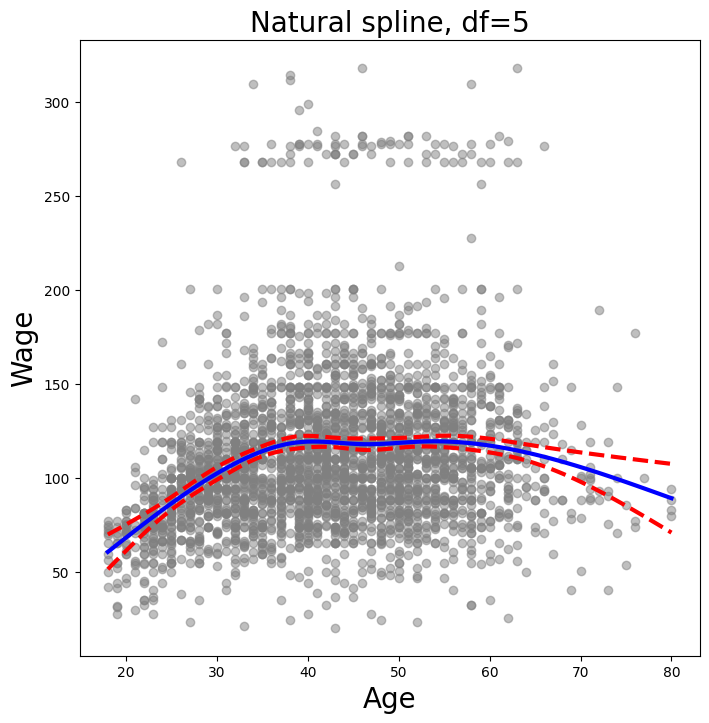

In [46]:
plot_wage_fit(age_df,
              ns_age,
              'Natural spline, df=5');

In [48]:
X_age = np.asarray(age).reshape((-1,1))
gam = LinearGAM(s_gam(0, lam=0.6))
gam.fit(X_age, y)

LinearGAM(callbacks=[Deviance(), Diffs()], fit_intercept=True, 
   max_iter=100, scale=None, terms=s(0) + intercept, tol=0.0001, 
   verbose=False)

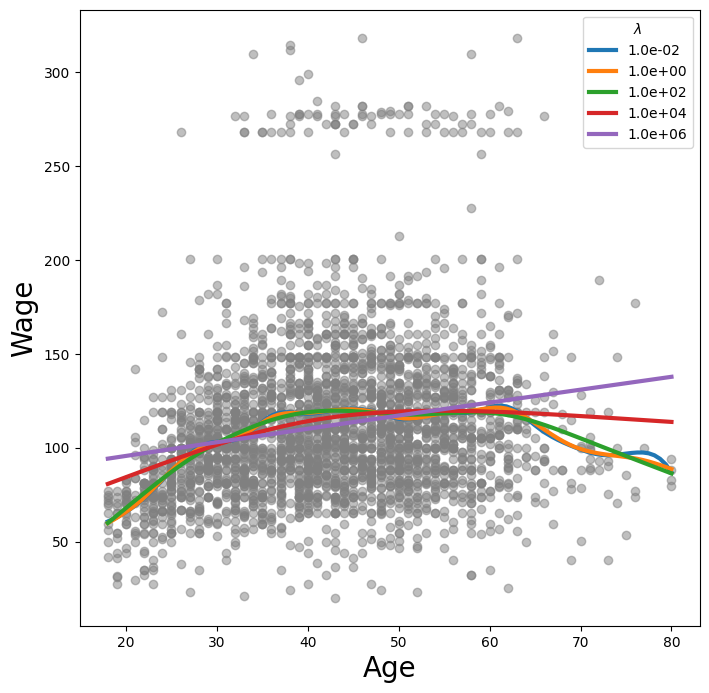

In [49]:
fig, ax = subplots(figsize=(8,8))
ax.scatter(age, y, facecolor='gray', alpha=0.5)
for lam in np.logspace(-2, 6, 5):
    gam = LinearGAM(s_gam(0, lam=lam)).fit(X_age, y)
    ax.plot(age_grid,
            gam.predict(age_grid),
            label='{:.1e}'.format(lam),
            linewidth=3)
ax.set_xlabel('Age', fontsize=20)
ax.set_ylabel('Wage', fontsize=20);
##ax.legend(title='$\lambda$');
ax.legend(title=r'$\lambda$');

100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00


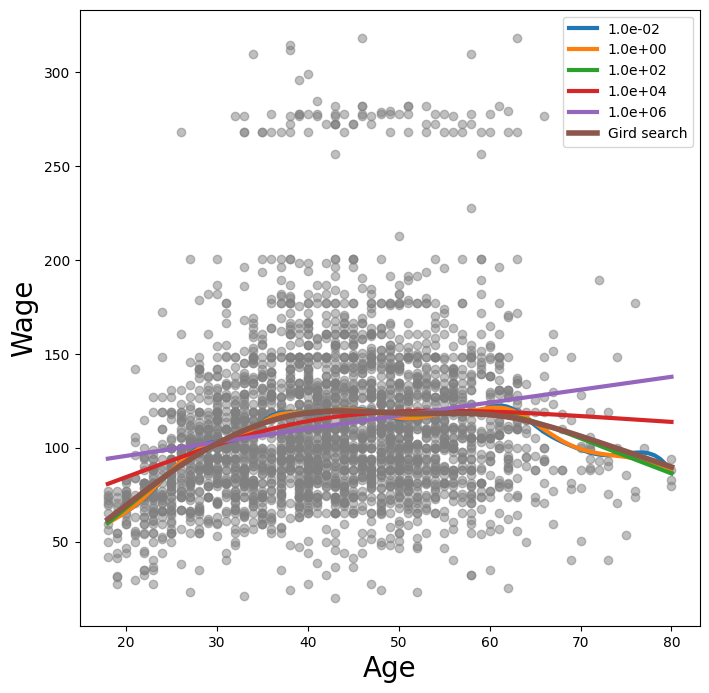

In [50]:
gam_opt = gam.gridsearch(X_age, y)
ax.plot(age_grid, gam_opt.predict(age_grid),label = 'Gird search', linewidth=4)
ax.legend()
fig

In [52]:
sm.nonparametric.lowess?

Signature:
sm.nonparametric.lowess(
    endog,
    exog,
    frac=0.6666666666666666,
    it=3,
    delta=0.0,
    xvals=None,
    is_sorted=False,
    missing='drop',
    return_sorted=True,
)
Docstring:
LOWESS (Locally Weighted Scatterplot Smoothing)

A lowess function that outs smoothed estimates of endog
at the given exog values from points (exog, endog)

Parameters
----------
endog : 1-D numpy array
    The y-values of the observed points
exog : 1-D numpy array
    The x-values of the observed points
frac : float
    Between 0 and 1. The fraction of the data used
    when estimating each y-value.
it : int
    The number of residual-based reweightings
    to perform.
delta : float
    Distance within which to use linear-interpolation
    instead of weighted regression.
xvals: 1-D numpy array
    Values of the exogenous variable at which to evaluate the regression.
    If supplied, cannot use delta.
is_sorted : bool
    If False (default), then the data will be sorted by exog before

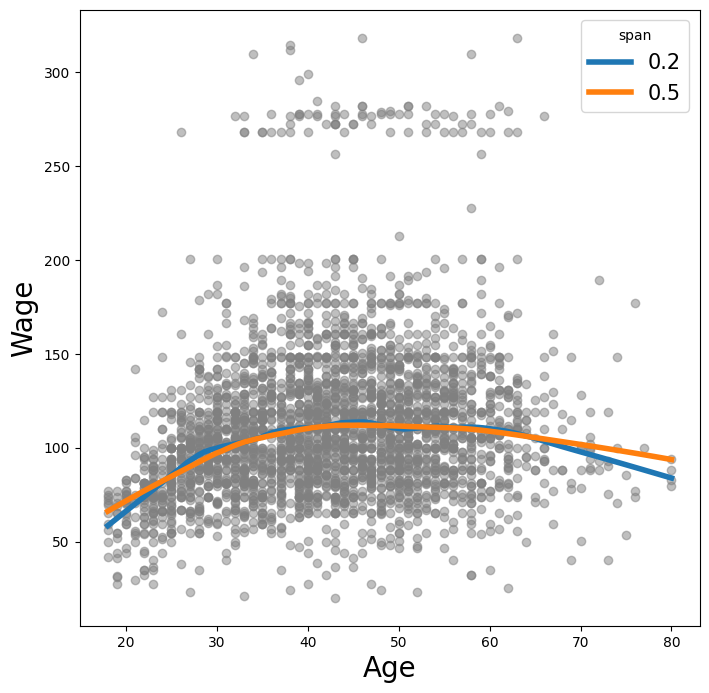

In [53]:
lowess = sm.nonparametric.lowess
fig, ax = subplots(figsize=(8,8))
ax.scatter(age, y, facecolor='gray', alpha=0.5)
for span in [0.2, 0.5]:
    fitted = lowess(y,
                    age,
                    frac=span,
                    xvals=age_grid)
    ax.plot(age_grid,
            fitted,
            label='{:.1f}'.format(span),
            linewidth=4)
ax.set_xlabel('Age', fontsize=20)
ax.set_ylabel('Wage', fontsize=20);
ax.legend(title='span', fontsize=15);